# A little curiosity. A clearer picture.
**Quanta showcase** · Python, data, and discovery on your Mac.

Explore a fictional solar-powered studio: follow its energy production, inspect native tables, and turn measurements into plots. All data is synthetic and generated locally with a fixed seed.

## Start here
Select an environment with **numpy, pandas, matplotlib, plotly, and scikit-learn**, then run all cells with **⌘R**. Install missing packages in that environment from a terminal:

```sh
python -m pip install numpy pandas matplotlib plotly scikit-learn
```

Use **Outline (⌘5)** to jump between sections. The notebook runs without network access and creates sample CSV and SQLite files in a temporary demo folder.

In [1]:
from pathlib import Path
import sqlite3
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
from sklearn import set_config
from sklearn.linear_model import LinearRegression

set_config(display="text")

rng = np.random.default_rng(42)
palette = {"solar": "#6d8bff", "studio": "#e8ad59"}
plt.rcParams.update({"figure.figsize": (10, 3.5), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

## 01 · From measurements to a table
A year of daily observations, with a seasonal solar signal and a separate studio-demand pattern. Double-click **energy** in Variables to open the full table; sort a column, filter rows, or copy original values.

In [2]:
dates = pd.date_range("2025-01-01", periods=365, freq="D")
day = np.arange(len(dates))
solar = np.clip(24 + 15 * np.sin(2 * np.pi * (day - 80) / 365)
                + rng.normal(0, 3.5, len(day)), 0, None)
demand = 23 + 4 * np.cos(2 * np.pi * day / 7) + rng.normal(0, 2, len(day))
energy = pd.DataFrame({"date": dates, "solar_kwh": solar.round(2),
                       "studio_kwh": demand.round(2)})
energy["balance_kwh"] = (energy.solar_kwh - energy.studio_kwh).round(2)
energy["season"] = energy.date.dt.month.map(
    {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring",
     6: "Summer", 7: "Summer", 8: "Summer", 9: "Autumn", 10: "Autumn", 11: "Autumn"})
energy.head(6)

Index,date,solar_kwh,studio_kwh,balance_kwh,season
0,2025-01-01,10.35,29.96,-19.61,Winter
1,2025-01-02,5.69,24.01,-18.32,Winter
2,2025-01-03,12.02,20.47,-8.45,Winter
3,2025-01-04,12.74,19.8,-7.06,Winter
4,2025-01-05,2.69,21.08,-18.39,Winter
5,2025-01-06,5.03,22.13,-17.1,Winter


## 02 · See the pattern
Daily solar production and studio demand, summarized as weekly means. A shared Python session keeps the same data available in your notebook, console, and Variables inspector.

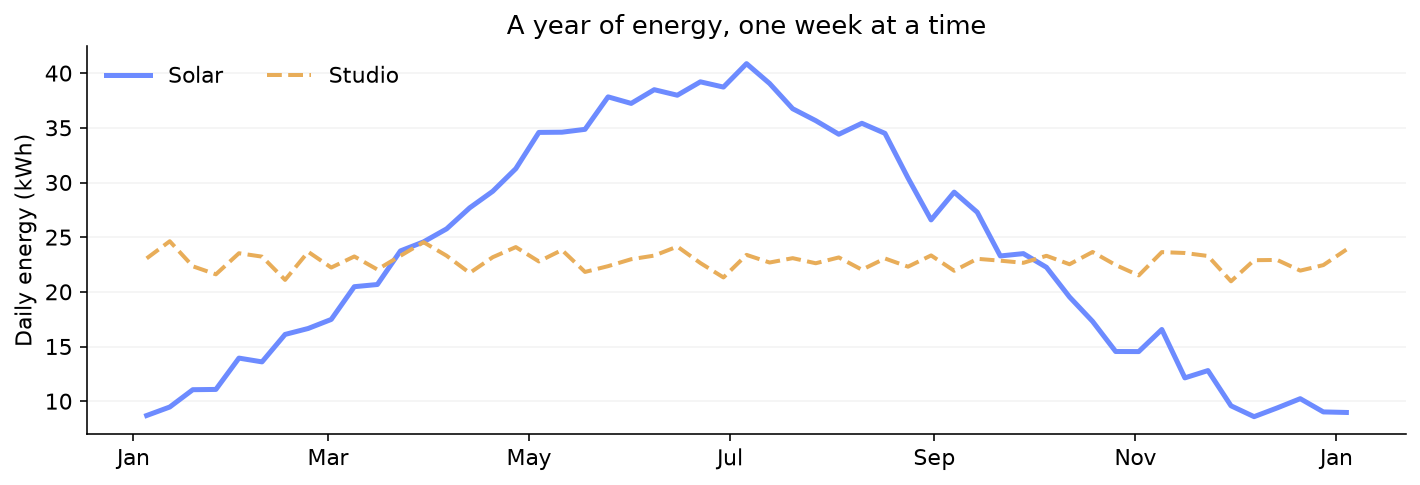

In [3]:
weekly = energy.set_index("date")[["solar_kwh", "studio_kwh"]].resample("W").mean()
fig, ax = plt.subplots()
ax.plot(weekly.index, weekly.solar_kwh, color=palette["solar"], lw=2.5, label="Solar")
ax.plot(weekly.index, weekly.studio_kwh, color=palette["studio"], lw=2, ls="--", label="Studio")
ax.set(title="A year of energy, one week at a time", ylabel="Daily energy (kWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(frameon=False, ncol=2, loc="upper left")
ax.grid(axis="y", alpha=0.15)
fig.tight_layout()
plt.show()

## 03 · Compare the seasons
A compact aggregation becomes another native DataFrame. These are means of daily observations, not seasonal totals.

In [4]:
seasonal = energy.groupby("season")[["solar_kwh", "studio_kwh", "balance_kwh"]].mean()
seasonal = seasonal.reindex(["Winter", "Spring", "Summer", "Autumn"]).round(2)
seasonal

Index,solar_kwh,studio_kwh,balance_kwh
Winter,11.8,22.87,-11.07
Spring,29.11,22.94,6.17
Summer,35.99,22.83,13.16
Autumn,18.65,22.72,-4.07


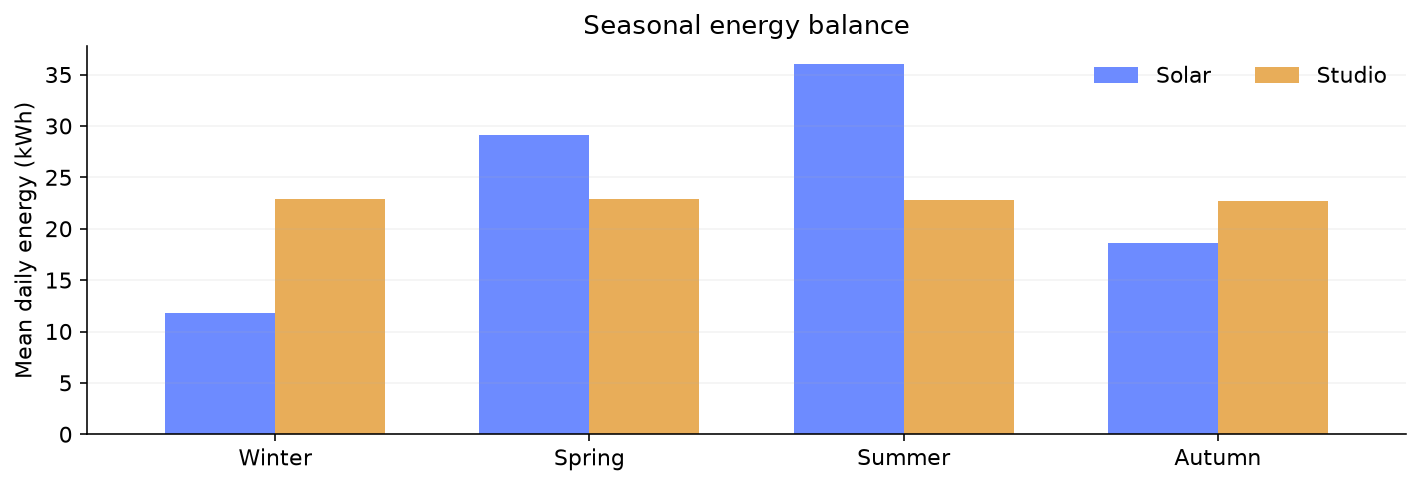

In [5]:
ax = seasonal[["solar_kwh", "studio_kwh"]].plot.bar(
    color=[palette["solar"], palette["studio"]], rot=0, width=0.7)
ax.set(title="Seasonal energy balance", xlabel="", ylabel="Mean daily energy (kWh)")
ax.legend(["Solar", "Studio"], frameon=False, ncol=2)
ax.grid(axis="y", alpha=0.15)
plt.tight_layout()
plt.show()

## 04 · Explore an interactive figure
Hover for exact values, drag to zoom, and double-click to reset. Plotly figures remain interactive when reopened in Quanta and in HTML exports.

In [6]:
interactive = px.scatter(
    energy, x="studio_kwh", y="solar_kwh", color="season",
    hover_data={"date": "|%b %d", "balance_kwh": ":.2f"},
    category_orders={"season": ["Winter", "Spring", "Summer", "Autumn"]},
    color_discrete_sequence=["#6d8bff", "#59b9a4", "#e8ad59", "#b78be8"],
    labels={"studio_kwh": "Studio demand (kWh)", "solar_kwh": "Solar production (kWh)"},
    title="Every day has a different energy balance")
interactive.update_layout(height=390, margin=dict(l=55, r=25, t=55, b=45))
interactive.update_traces(marker=dict(size=7, opacity=0.8))
interactive

Plotly figure

## 05 · Explain it with math
Markdown headings, tables, and equations stay beside the code.

$$B_d = S_d - D_d, \qquad \bar{B} = \frac{1}{n}\sum_{d=1}^{n} B_d$$

| Symbol | Meaning | Unit |
| --- | --- | --- |
| $S_d$ | Solar production on day $d$ | kWh |
| $D_d$ | Studio demand on day $d$ | kWh |
| $B_d$ | Daily production minus demand | kWh |

Positive balance means production exceeded demand on that day. This simplified example does not model storage, tariffs, or transfers within a day.

In [7]:
summary = {
    "dataset": "Synthetic studio energy · 2025",
    "observations": len(energy),
    "totals_kwh": {"solar": round(float(energy.solar_kwh.sum()), 2),
                   "studio": round(float(energy.studio_kwh.sum()), 2)},
    "daily_balance": {"mean_kwh": round(float(energy.balance_kwh.mean()), 2),
                      "surplus_days": int((energy.balance_kwh > 0).sum())},
    "provenance": {"seed": 42, "source": "Generated in this notebook", "real_measurements": False},
}
summary

{'dataset': 'Synthetic studio energy · 2025', 'observations': 365, 'totals_kwh': {'solar': 8748.57, 'studio': 8336.71}, 'daily_balance': {'mean_kwh': 1.13, 'surplus_days': 195}, 'provenance': {'seed': 42, 'source': 'Generated in this notebook', 'real_measurements': False}}

## 06 · Inspect arrays and fitted models
The same observations can be inspected as a NumPy array or used to fit a small model. Quanta shows native array previews and scikit-learn model cards.

In [8]:
correlations = energy[["solar_kwh", "studio_kwh", "balance_kwh"]].corr().to_numpy()
correlations

array([[ 1.        ,  0.0268803 ,  0.95356071],
       [ 0.0268803 ,  1.        , -0.27546004],
       [ 0.95356071, -0.27546004,  1.        ]])

In [9]:
season_angle = 2 * np.pi * (day - 80) / 365
features = np.column_stack([np.sin(season_angle), np.cos(season_angle)])
model = LinearRegression().fit(features, energy.solar_kwh)
fitted_solar = model.predict(features)
model._repr_mimebundle_ = None
model

LinearRegression()

### Fit and inspect
The line is an in-sample seasonal fit to synthetic data; it is not a forecast. The model, features, and predictions are available in Variables.

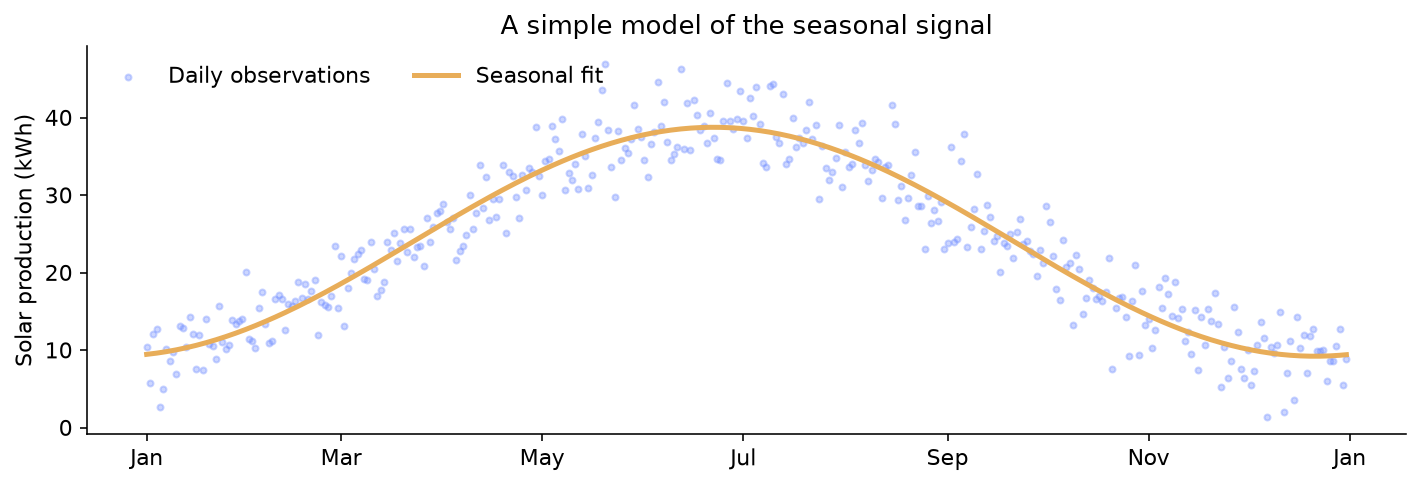

In [10]:
fig, ax = plt.subplots()
ax.scatter(energy.date, energy.solar_kwh, s=9, alpha=0.35,
           color=palette["solar"], label="Daily observations")
ax.plot(energy.date, fitted_solar, color=palette["studio"], lw=2.5, label="Seasonal fit")
ax.set(title="A simple model of the seasonal signal", ylabel="Solar production (kWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(frameon=False, ncol=2, loc="upper left")
fig.tight_layout()
plt.show()

## 07 · Take the data into SQL
This cell creates **energy.csv** and **energy.sqlite** in a temporary demo folder. Open either with **Data → Open Data Source…** to explore tables, inspect columns, and run read-only SQL without a Python session.

The example also executes the same aggregation using Python's standard-library SQLite connection.

In [11]:
demo_folder = Path(tempfile.gettempdir()) / "quanta-showcase"
demo_folder.mkdir(exist_ok=True)
energy.to_csv(demo_folder / "energy.csv", index=False)
with sqlite3.connect(demo_folder / "energy.sqlite") as connection:
    energy.to_sql("energy", connection, index=False, if_exists="replace")
    sql_summary = pd.read_sql_query("""
        SELECT season, COUNT(*) AS days,
               ROUND(AVG(solar_kwh), 2) AS solar_kwh,
               ROUND(AVG(studio_kwh), 2) AS studio_kwh,
               ROUND(AVG(balance_kwh), 2) AS balance_kwh
        FROM energy GROUP BY season ORDER BY solar_kwh DESC
    """, connection)
print(f"Demo files: {demo_folder}")
sql_summary

Demo files: /var/folders/kd/5lgkq9vn7yx8fz6k3s_hp6100000gn/T/quanta-showcase


Index,season,days,solar_kwh,studio_kwh,balance_kwh
0,Summer,92,35.99,22.83,13.16
1,Spring,92,29.11,22.94,6.17
2,Autumn,91,18.65,22.72,-4.07
3,Winter,90,11.8,22.87,-11.07


## 08 · Check and keep exploring
The checks below verify the sample's grain, missing values, energy arithmetic, and SQL aggregation. Try typing `energy.` and pressing **⌃Space** for live completions; use **⇧Tab** for documentation.

In [12]:
assert len(energy) == 365 and energy.date.is_unique
assert not energy.isna().any().any()
assert np.allclose(energy.balance_kwh, energy.solar_kwh - energy.studio_kwh)
assert int(sql_summary.days.sum()) == len(energy)
assert np.allclose(sql_summary.set_index("season").solar_kwh,
                   seasonal.loc[sql_summary.season, "solar_kwh"])
print("All checks passed · 365 daily observations · 4 seasons")

All checks passed · 365 daily observations · 4 seasons


## Make it your workspace
- **Outline:** jump between sections with **⌘5**; filter headings and cells.
- **Variables:** open **energy**, inspect **summary**, and explore **features**.
- **Plots:** choose **Navigate → Show Plots** to revisit all four figures and export one.
- **Console:** evaluate `energy.balance_kwh.mean()` in the shared Python session.
- **Cell actions:** select a cell to reveal its floating toolbar; move, duplicate, collapse, or change its type.
- **Local data:** open the generated CSV or SQLite file in the Data navigator.
- **Export:** use **File → Export Notebook** for HTML or PDF.
- **Git:** save a copy in a repository, edit a cell, and review the source-focused diff.

Quanta supports ordinary Python and Jupyter notebook files through its own Python bridge. IPython magics, shell escapes, and interactive Jupyter widgets are outside this example.